# moscow CI(ty)NEMAS

в детстве я ходила смотреть кино в несколько кинотеатров на районе. в какой-то момент вдруг оказалось, что они все закрыты. некоторые потом перестраивали, и они становились другими. вообще я слышала это постоянно - "будут сносить кинотеатр какой-то там", "вместо кинотеатра откроют большой развлекательный центр", "приходите в новый современный кинотеатр на месте исторического здания"

два из тех кинотеатров, которые я помню, были названы в честь городов. один снесли, другой до сих пор стоит, но заброшенный

мне всегда было интересно, сколько ещё в москве таких было, когда они открывались, в честь каких городов их называли и осталось ли от них что-то сейчас?

названия советских кинотеатров - не просто вывески. они отражают идеологию - отсылают к историческим событиям, важным местам и другим культурным мотивам

Исследовательский вопрос: как геополитические связи советского союза отражаются в названиях московских кинотеатров, названных в честь городов, и как меняется их присутствие с течением времени?

# Импорты, настройка, папки

In [77]:
import json
import time
import requests
import zipfile
import shutil
import pandas as pd
from io import StringIO
from pathlib import Path
from urllib.parse import quote

import matplotlib.pyplot as plt
import folium

# Настройки
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 110)
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 130, 'savefig.bbox': 'tight'})

# Папки
for folder in ['data', 'data/raw', 'outputs']:
    Path(folder).mkdir(parents=True, exist_ok=True)

print("✓ Импорты и папки готовы")

✓ Импорты и папки готовы


# rawrxd

из википедии

In [78]:
url = 'https://ru.wikipedia.org/wiki/' + quote('Кинотеатры_Москвы')  # URL с кодированием

headers = {                                                          # я
    'User-Agent': 'Lisa (https://github.com/belskayaelv/moscow-ci-ty-nemas)'
}

response = requests.get(url, headers=headers, timeout=10)            # запрос
response.encoding = 'utf-8'                                          # кодировка

html = response.text                                                 # HTML в строку
tables = pd.read_html(StringIO(html))                                # все таблицы

print(f"Статус: {response.status_code}")                             # 200 = ок
print(f"Найдено таблиц: {len(tables)}")                              # сколько
for i, t in enumerate(tables):                                       # размеры
    print(f"  Таблица {i}: {t.shape}")

Статус: 200
Найдено таблиц: 4
  Таблица 0: (62, 7)
  Таблица 1: (3, 6)
  Таблица 2: (5, 8)
  Таблица 3: (119, 7)


сохранить в raw


In [79]:
raw_dir = Path('data/raw')                               # папка raw
raw_dir.mkdir(parents=True, exist_ok=True)

# 1. HTML-страница
with open(raw_dir / 'source_page.html', 'w', encoding='utf-8') as f:
    f.write(html)                                        # сохранить HTML

# 2. Таблицы как JSON
tables_data = {
    "source": "https://ru.wikipedia.org/wiki/Кинотеатры_Москвы",
    "num_tables": len(tables),
    "tables": [
        {"index": i, "shape": list(t.shape),
         "columns": t.columns.tolist(),
         "rows": t.to_dict(orient='records')}
        for i, t in enumerate(tables)
    ],
}

with open(raw_dir / 'parsed_rows.json', 'w', encoding='utf-8') as f:
    json.dump(tables_data, f, ensure_ascii=False, indent=2)

print(f"✓ source_page.html: {(raw_dir / 'source_page.html').stat().st_size / 1024:.1f} КБ")
print(f"✓ parsed_rows.json: {(raw_dir / 'parsed_rows.json').stat().st_size / 1024:.1f} КБ")
print(f"  Таблиц: {len(tables)}")

✓ source_page.html: 341.1 КБ
✓ parsed_rows.json: 72.5 КБ
  Таблиц: 4


из geonames

In [80]:
raw_dir = Path('data/raw')
zip_path = raw_dir / 'cities15000.zip'
txt_path = raw_dir / 'cities15000.txt'

# geonames
if not txt_path.exists():
    if not zip_path.exists():
        url = "https://download.geonames.org/export/dump/cities15000.zip"
        r = requests.get(url, stream=True)
        with open(zip_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(raw_dir)

# кэш
cache_file = raw_dir / 'nominatim_cache.json'
if not cache_file.exists():
    with open(cache_file, 'w', encoding='utf-8') as f:
        json.dump({}, f, ensure_ascii=False, indent=2)

print(f"✓ cities15000.txt: {txt_path.stat().st_size / 1024 / 1024:.1f} МБ")
print(f"✓ nominatim_cache.json: {cache_file.stat().st_size} Б")

✓ cities15000.txt: 8.0 МБ
✓ nominatim_cache.json: 2553 Б


проверка rawrxd

In [81]:
raw_dir = Path('data/raw')
print(f"Содержимое {raw_dir}/:\n")
for f in sorted(raw_dir.iterdir()):
    size = f.stat().st_size
    s = f"{size / 1024 / 1024:.1f} МБ" if size > 1024*1024 else f"{size / 1024:.1f} КБ"
    print(f"  {f.name:30s} {s}")

Содержимое data/raw/:

  cities15000.txt                8.0 МБ
  cities15000.zip                3.2 МБ
  nominatim_cache.json           2.5 КБ
  parsed_rows.json               72.5 КБ
  source_page.html               341.1 КБ


# кинотеатры и города

только нужное из таблиц

In [82]:
def keep_only_needed(table):
    keywords = ['Название', 'открыт', 'закрыт', 'Адрес']
    columns_to_keep = [c for c in table.columns if any(w in c for w in keywords)]
    return table[columns_to_keep]

t0 = keep_only_needed(tables[0])
t3 = keep_only_needed(tables[3])

df = pd.concat([t0, t3], ignore_index=True)

print(f"Форма: {df.shape}")
print(f"Столбцы: {df.columns.tolist()}")
df.head()

Форма: (181, 4)
Столбцы: ['Название', 'Год (дата) открытия', 'Адрес', 'Год (дата) закрытия']


,Название,Год (дата) открытия,Адрес,Год (дата) закрытия
0,Балтика*,2012.12.08,"Сходненская улица, 56",NaN
1,Берёзка,1962.12.31,"Мартеновская, 25",NaN
2,Вымпел (до 1964 — Спутник),1959,"Коминтерна, 8",NaN
3,ГУМ,2011,"Красная площадь, 3",NaN
4,Домжур,2009,"Никитский бульвар, 8а",NaN


города

In [83]:
columns = [
    'geonameid', 'name', 'asciiname', 'alternatenames',
    'latitude', 'longitude',
    'feature_class', 'feature_code',
    'country_code', 'cc2',
    'admin1_code', 'admin2_code', 'admin3_code', 'admin4_code',
    'population', 'elevation', 'dem', 'timezone', 'modification_date'
]

cities = pd.read_csv(
    'data/raw/cities15000.txt',
    sep='\t', header=None, names=columns,
    encoding='utf-8', low_memory=False, quoting=3,
)

print(f"✓ Городов: {len(cities):,}")
cities.head(3)

✓ Городов: 34,136


,geonameid,name,asciiname,alternatenames,latitude,longitude,feature_class,feature_code,country_code,cc2,admin1_code,admin2_code,admin3_code,admin4_code,population,elevation,dem,timezone,modification_date
0,3040051,les Escaldes,les Escaldes,"Ehskal'des-Ehndzhordani,Ehskal'des-Ehngordani,Escaldes,Escaldes-Engordany,Les Escaldes,aisakaladesa-inagor...",42.50729,1.53414,P,PPLA,AD,NaN,08,NaN,NaN,NaN,15853,NaN,1033,Europe/Andorra,2026-04-13
1,3041563,Andorra la Vella,Andorra la Vella,"ALV,Ando-la-Vyey,Andora,Andora la Vela,Andora la Velja,Andora lja Vehl'ja,Andoro Malnova,Andorra,Andorra T...",42.50779,1.52109,P,PPLC,AD,NaN,07,NaN,NaN,NaN,20430,NaN,1037,Europe/Andorra,2020-03-03
2,290503,Warīsān,Warisan,"Warisan,Warsan,Warīsān,wrsan,ورسان",25.16744,55.40708,P,PPL,AE,NaN,03,NaN,NaN,NaN,108759,NaN,12,Asia/Dubai,2024-06-11


is city?

In [84]:
def is_city(name, min_population=10000):
    mask = (
        (cities['name'].str.lower() == str(name).lower()) |
        (cities['asciiname'].str.lower() == str(name).lower()) |
        (cities['alternatenames'].str.contains(str(name), case=False, na=False, regex=False))
    )
    found = cities[mask]
    if found.empty:
        return False, None

    found = found[found['feature_class'] == 'P']     # только населённые пункты
    if found.empty:
        return False, None

    biggest = found.loc[found['population'].idxmax()]
    if biggest['population'] < min_population:
        return False, None
    return True, biggest

якобы города

In [85]:
names = sorted(df['Название'].dropna().unique())

results = []
for n in names:
    ok, c = is_city(n)
    results.append({'Название': n, 'is_city': ok,
                    'geoname': c['name'] if ok else None,
                    'country': c['country_code'] if ok else None})

res_df = pd.DataFrame(results)
print(f"Всего: {len(res_df)}, из них is_city=True: {res_df['is_city'].sum()}\n")
res_df[res_df['is_city']]

Всего: 176, из них is_city=True: 58



,Название,is_city,geoname,country
3,Аврора,True,Aurora,US
8,Алтай,True,Jinshanlu,CN
9,Ангара,True,Mangaratiba,BR
12,Ашхабад,True,Ashgabat,TM
13,Байкал,True,Severobaykal’sk,RU
14,Байконур,True,Baikonur,KZ
15,Баку,True,Baku,AZ
21,Бородино,True,Borodino,RU
22,Брест,True,Brest,BY
23,Будапешт,True,Budapest,HU


реально города

In [86]:
real_cities = [
    'Ашхабад', 'Баку', 'Брест', 'Будапешт', 'Варшава',
    'Волгоград', 'Гавана', 'Ереван', 'Керчь', 'Киев',
    'Кишинёв', 'Ленинград', 'Минск', 'Одесса', 'Прага',
    'Рига', 'Севастополь', 'София', 'Таллин', 'Ташкент',
    'Тбилиси', 'Тула', 'Улан-Батор', 'Ханой',
]

city_cinemas = df[df['Название'].isin(real_cities)].copy()
city_cinemas['group'] = 'city'

print(f"Найдено: {len(city_cinemas)}")
print(city_cinemas['Название'].tolist())

Найдено: 24
['Тула', 'Ашхабад', 'Баку', 'Брест', 'Будапешт', 'Варшава', 'Волгоград', 'Гавана', 'Ереван', 'Керчь', 'Киев', 'Кишинёв', 'Ленинград', 'Минск', 'Одесса', 'Прага', 'Рига', 'Севастополь', 'София', 'Таллин', 'Ташкент', 'Тбилиси', 'Улан-Батор', 'Ханой']


распределение городов по группам

In [87]:
groups = {
    'Тула': 'РСФСР',
    'Волгоград': 'РСФСР',
    'Ленинград': 'РСФСР',

    'Ашхабад': 'союзная республика',
    'Баку': 'союзная республика',
    'Брест': 'союзная республика',
    'Ереван': 'союзная республика',
    'Керчь': 'союзная республика',
    'Киев': 'союзная республика',
    'Кишинёв': 'союзная республика',
    'Минск': 'союзная республика',
    'Одесса': 'союзная республика',
    'Рига': 'союзная республика',
    'Севастополь': 'союзная республика',
    'Таллин': 'союзная республика',
    'Ташкент': 'союзная республика',
    'Тбилиси': 'союзная республика',

    'Будапешт': 'соцстрана',
    'Варшава': 'соцстрана',
    'Гавана': 'соцстрана',
    'Прага': 'соцстрана',
    'София': 'соцстрана',
    'Улан-Батор': 'соцстрана',
    'Ханой': 'соцстрана',
}

city_cinemas['geo_group'] = city_cinemas['Название'].map(groups)

print(city_cinemas['geo_group'].value_counts())
print(f"\nБез группы: {city_cinemas['geo_group'].isna().sum()}")

geo_group
союзная республика    14
соцстрана              7
РСФСР                  3
Name: count, dtype: int64

Без группы: 0


кэш

In [88]:
CACHE_FILE = Path('data/raw/nominatim_cache.json')  # путь к блокноту
with open(CACHE_FILE, encoding='utf-8') as f:
    cache = json.load(f)

координаты кинотеатров по адресу```



In [89]:
def geocode(address):
    if address in cache:                            # уже искали?
        return cache[address]['lat'], cache[address]['lon']  # в блокноте
    r = requests.get(...)                           # иначе — в Nominatim
    data = r.json()                                 # ответ
    lat, lon = (...) if data else (None, None)      # результат?
    cache[address] = {'lat': lat, 'lon': lon}       # записывать в блокнот
    return lat, lon

In [90]:
CACHE_FILE = Path('data/raw/nominatim_cache.json')
with open(CACHE_FILE, encoding='utf-8') as f:
    cache = json.load(f)

def geocode(address):
    if address in cache:
        return cache[address]['lat'], cache[address]['lon']
    r = requests.get(
        "https://nominatim.openstreetmap.org/search",
        params={"q": address, "format": "json", "limit": 1},
        headers={"User-Agent": "Lisa (https://github.com/belskayelv/moscow-ci-ty-nemas)"},
        timeout=10,
    )
    data = r.json()
    if data:
        lat, lon = float(data[0]['lat']), float(data[0]['lon'])
    else:
        lat, lon = None, None
    cache[address] = {'lat': lat, 'lon': lon}
    return lat, lon

def save_cache():
    with open(CACHE_FILE, 'w', encoding='utf-8') as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)

lats, lons = [], []
for i, row in city_cinemas.iterrows():
    addr = f"Москва, {row['Адрес']}"
    lat, lon = geocode(addr)
    lats.append(lat); lons.append(lon)
    print(f"[{i+1}/{len(city_cinemas)}] {row['Название']}: {lat}, {lon}")
    time.sleep(1)

city_cinemas['lat'] = lats
city_cinemas['lon'] = lons
save_cache()

print(f"\nНайдено: {city_cinemas['lat'].notna().sum()}/{len(city_cinemas)}")

[21/24] Тула: 55.6858606, 37.7186241
[71/24] Ашхабад: 55.6241173, 37.5954202
[74/24] Баку: 55.8040678, 37.5334278
[79/24] Брест: 55.7359258, 37.4086052
[80/24] Будапешт: 55.8973764, 37.6045115
[82/24] Варшава: 55.8210035, 37.4991229
[87/24] Волгоград: 55.7064351, 37.8191832
[94/24] Гавана: 55.8103342, 37.6168206
[100/24] Ереван: 55.865059, 37.5494034
[105/24] Керчь: 55.5955562, 37.6641145
[106/24] Киев: 55.7411593, 37.5366098
[111/24] Кишинёв: 55.6985048, 37.7415586
[114/24] Ленинград: 55.7987821, 37.5133677
[122/24] Минск: 55.7166236, 37.4008379
[130/24] Одесса: 55.65282, 37.5753265
[142/24] Прага: 55.7926442, 37.5779826
[147/24] Рига: 55.8453647, 37.5831728
[154/24] Севастополь: 55.8015014, 37.7334905
[158/24] София: 55.8037728, 37.8005656
[162/24] Таллин: 55.6208585, 37.5436063
[163/24] Ташкент: 55.7172214, 37.7837754
[164/24] Тбилиси: 55.6717458, 37.569786
[168/24] Улан-Батор: 55.6895423, 37.5785342
[173/24] Ханой: 55.6137577, 37.5388227

Найдено: 24/24


координаты городов

In [91]:
ref_lats, ref_lons, ref_countries = [], [], []

for name in city_cinemas['Название']:
    ok, c = is_city(name)
    if ok:
        ref_lats.append(c['latitude'])
        ref_lons.append(c['longitude'])
        ref_countries.append(c['country_code'])
    else:
        ref_lats.append(None)
        ref_lons.append(None)
        ref_countries.append(None)

city_cinemas['referent_lat'] = ref_lats
city_cinemas['referent_lon'] = ref_lons
city_cinemas['referent_country'] = ref_countries

print(f"Найдено: {city_cinemas['referent_lat'].notna().sum()}/{len(city_cinemas)}")

Найдено: 24/24


годы и статус

In [92]:
# ЯЧЕЙКА 13. ГОДЫ + СТАТУС

# год открытия
city_cinemas['year'] = pd.to_numeric(
    city_cinemas['Год (дата) открытия'].astype(str).str.extract(r'(\d{4})')[0],
    errors='coerce'
).astype('Int64')

# год закрытия
city_cinemas['close_year'] = pd.to_numeric(
    city_cinemas['Год (дата) закрытия'].astype(str).str.extract(r'(\d{4})')[0],
    errors='coerce'
).astype('Int64')

# правки         - в таблице не было данных
manual_closed = {'Киев': 1997, 'Одесса': 2003, 'Севастополь': 1992, 'Кишинёв': 2000}

for name, yr in manual_closed.items():
    idx = city_cinemas[city_cinemas['Название'] == name].index[0]
    city_cinemas.loc[idx, 'close_year'] = yr


# Статус
def get_status(row):
    if row['Название'] == 'Тула':
        return 'работает'
    if pd.notna(row['close_year']):
        return 'закрыт'
    return 'нет данных'

city_cinemas['status'] = city_cinemas.apply(get_status, axis=1)

# Десятилетия
city_cinemas['decade'] = (city_cinemas['year'] // 10 * 10).astype('Int64')

print(city_cinemas[['Название', 'year', 'close_year', 'status', 'decade']])

        Название  year  close_year    status  decade
20          Тула  1988        <NA>  работает    1980
70       Ашхабад  1973        2012    закрыт    1970
73          Баку  1974        2019    закрыт    1970
78         Брест  1967        2015    закрыт    1960
79      Будапешт  1981        2011    закрыт    1980
81       Варшава  1970        2014    закрыт    1970
86     Волгоград  1987        2009    закрыт    1980
93        Гавана  1986        2011    закрыт    1980
99        Ереван  1970        1990    закрыт    1970
104        Керчь  1979        2018    закрыт    1970
105         Киев  1957        1997    закрыт    1950
110      Кишинёв  1966        2000    закрыт    1960
113    Ленинград  1959        2011    закрыт    1950
121        Минск  1972        2005    закрыт    1970
129       Одесса  1966        2003    закрыт    1960
141        Прага  1975        2018    закрыт    1970
146         Рига  1966        2007    закрыт    1960
153  Севастополь  1964        1992    закрыт  

сохранить датасет

In [93]:
data_out = {
    "source": "https://ru.wikipedia.org/wiki/Кинотеатры_Москвы",
    "cinemas": city_cinemas.to_dict(orient='records'),
}

with open('data/research_data.json', 'w', encoding='utf-8') as f:
    json.dump(data_out, f, ensure_ascii=False, indent=2)

city_cinemas.to_csv('outputs/all_cinemas.csv', index=False, encoding='utf-8')

print(f"✓ research_data.json: {len(city_cinemas)} записей")
print(f"✓ all_cinemas.csv")
print(f"Столбцы: {city_cinemas.columns.tolist()}")

✓ research_data.json: 24 записей
✓ all_cinemas.csv
Столбцы: ['Название', 'Год (дата) открытия', 'Адрес', 'Год (дата) закрытия', 'group', 'geo_group', 'lat', 'lon', 'referent_lat', 'referent_lon', 'referent_country', 'year', 'close_year', 'status', 'decade']


# карты

попап

In [94]:
def make_popup(row):
    closed = row['close_year']
    if pd.isna(closed):
        closed_str = '—'
    else:
        closed_str = int(closed)

    return f"""
    <b>{row['Название']}</b><br>
    Адрес: {row['Адрес']}<br>
    Открыт: {int(row['year'])}<br>
    Закрыт: {closed_str}<br>
    Тип: {row['geo_group']}<br>
    Статус: {row['status']}
    """

карта со слоями

In [104]:
import folium

colors = {'РСФСР': 'blue', 'союзная республика': 'red', 'соцстрана': 'orange'}

m = folium.Map(
    location=[50, 40], zoom_start=3,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='© Esri',
)

decades = [1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]

for dec in decades:
    dec_end = dec + 9
    alive = city_cinemas[
        (city_cinemas['year'] <= dec_end) &
        ((city_cinemas['close_year'].isna()) | (city_cinemas['close_year'] >= dec))
    ]

    fg = folium.FeatureGroup(name=f"{dec}-е ({len(alive)})", show=(dec == 2000))

    for _, row in alive.iterrows():
        if pd.isna(row['lat']):
            continue
        c = colors.get(row['geo_group'], 'gray')

        folium.CircleMarker(
            [row['lat'], row['lon']], radius=5,
            color=c, fill=True, fill_color=c, fill_opacity=0.9,
            popup=make_popup(row),
            tooltip=row['Название'],
        ).add_to(fg)

        folium.map.Marker(
            [row['lat'], row['lon']],
            icon=folium.DivIcon(
                html=f'<div style="font-size:14px;color:white;">{row["Название"]}</div>',
                icon_size=(0, 0),
                icon_anchor=(20, -5),
            ),
        ).add_to(fg)

    fg.add_to(m)

folium.LayerControl(collapsed=True).add_to(m)
m.save('outputs/map_layers.html')
m

карта с линиями

In [96]:
m = folium.Map(
    location=[50, 40], zoom_start=3,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='© Esri',
)

for _, row in city_cinemas.iterrows():
    if pd.isna(row['lat']) or pd.isna(row['referent_lat']):
        continue

    c = colors.get(row['geo_group'], 'gray')

    # 1. Кинотеатр — точка без подписи
    folium.CircleMarker(
        [row['lat'], row['lon']], radius=5,
        color=c, fill=True, fill_color=c, fill_opacity=0.9,
        popup=make_popup(row),
        tooltip=row['Название'],
    ).add_to(m)

    # 2. Линия к городу
    folium.PolyLine(
        [[row['lat'], row['lon']], [row['referent_lat'], row['referent_lon']]],
        color=c, weight=2, opacity=0.6,
    ).add_to(m)

    # 3. Город — точка
    folium.CircleMarker(
        [row['referent_lat'], row['referent_lon']], radius=5,
        color=c, fill=True, fill_color=c, fill_opacity=0.7,
        popup=f"{row['Название']} — город",
    ).add_to(m)

    # 4. Подпись города
    folium.map.Marker(
        [row['referent_lat'], row['referent_lon']],
        icon=folium.DivIcon(
            html=f'<div style="font-size:14px;color:white;">{row["Название"]}</div>',
            icon_size=(0, 0),
            icon_anchor=(18, 0),
        ),
    ).add_to(m)

m.save('outputs/map_lines.html')
m

# графики

период работы

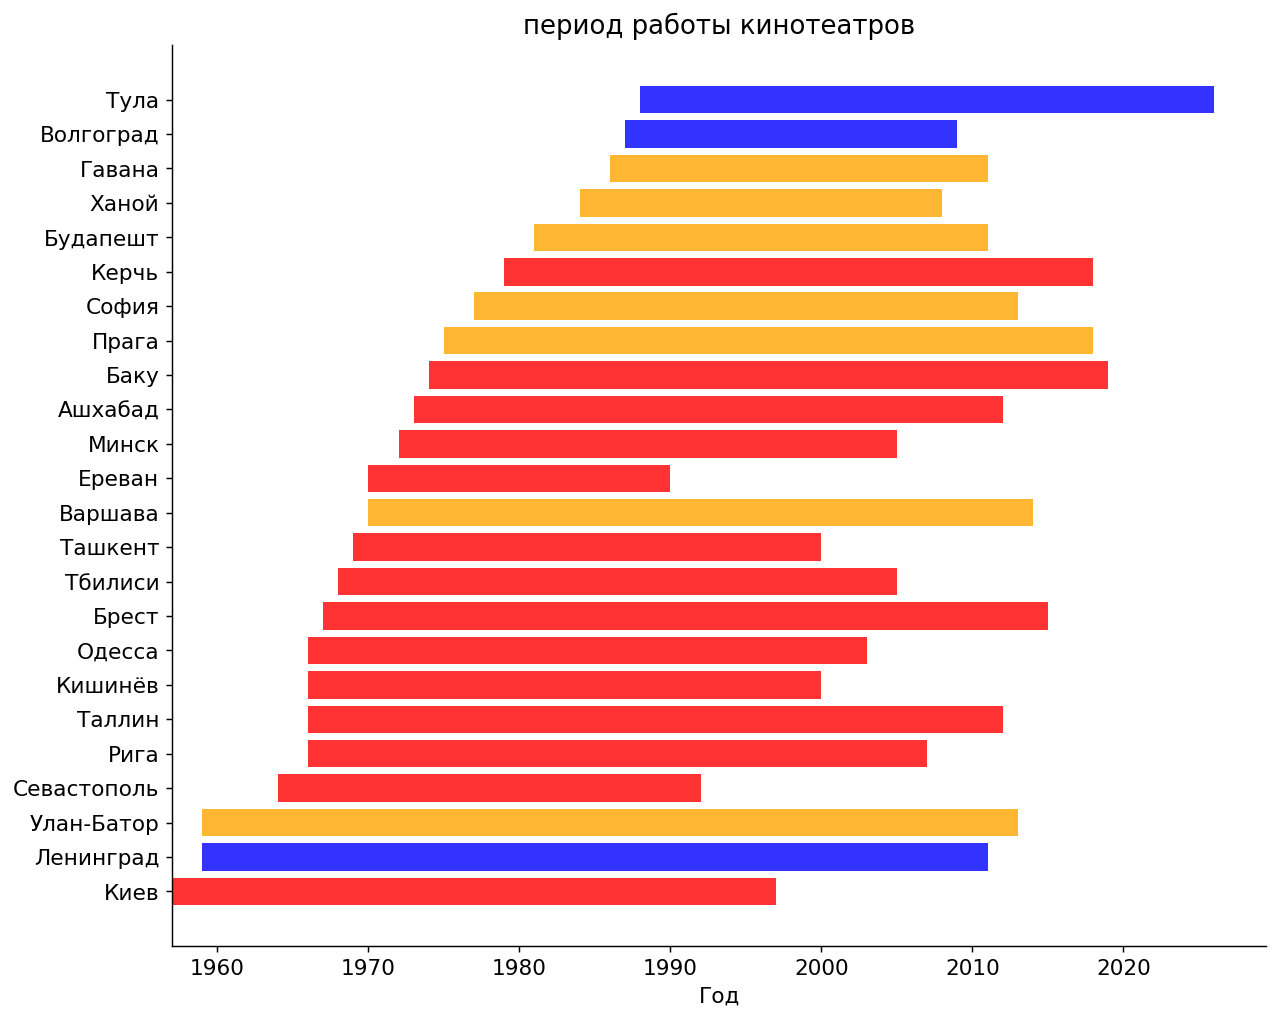

In [97]:
fig, ax = plt.subplots(figsize=(10, 8))
sorted_df = city_cinemas.sort_values('year')
colors_map = {'РСФСР': 'blue', 'союзная республика': 'red', 'соцстрана': 'orange'}

for i, (_, row) in enumerate(sorted_df.iterrows()):
    end = row['close_year'] if pd.notna(row['close_year']) else 2026
    ax.barh(i, end - row['year'], left=row['year'],
            color=colors_map.get(row['geo_group'], 'gray'), alpha=0.8)

ax.set_yticks(range(len(sorted_df)))
ax.set_yticklabels(sorted_df['Название'])
ax.set_xlabel('Год')
ax.set_title('период работы кинотеатров')
plt.tight_layout()
plt.savefig('outputs/fig_lifespan.png', dpi=130)
plt.show()

открытия

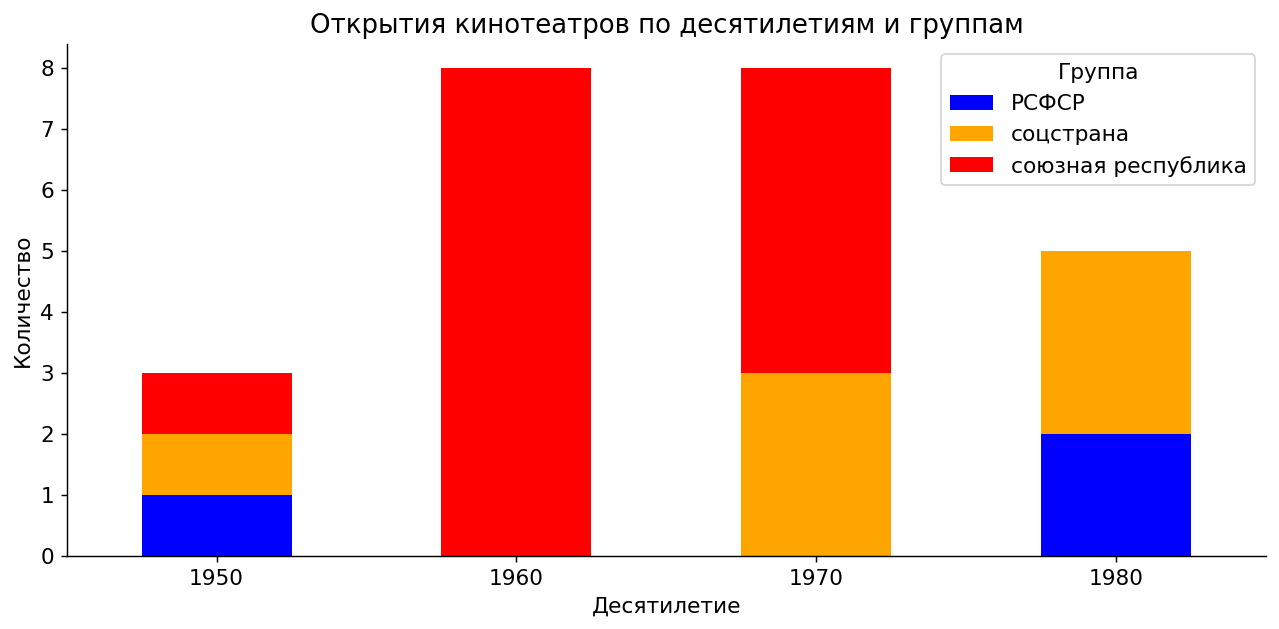

In [98]:
pivot = city_cinemas.groupby(['decade', 'geo_group']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', stacked=True, ax=ax,
           color={'РСФСР': 'blue', 'союзная республика': 'red', 'соцстрана': 'orange'})
ax.set_title('Открытия кинотеатров по десятилетиям и группам')
ax.set_xlabel('Десятилетие')
ax.set_ylabel('Количество')
ax.legend(title='Группа')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/fig_decades_groups.png', dpi=130)
plt.show()

выводы

In [110]:
from google.colab import files
files.download('outputs/all_cinemas.csv')
files.download('data/research_data.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [111]:
files.download('outputs/map_layers.html')
files.download('outputs/map_lines.html')
files.download('outputs/fig_lifespan.png')
files.download('outputs/fig_decades_groups.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [112]:
files.download('data/raw/parsed_rows.json')
files.download('data/raw/source_page.html')
files.download('data/raw/nominatim_cache.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>